# Рубежный контроль №1 (ТМО)

**Студент:** Фролов Илья  
**Группа:** ИУ5-62Б  
**Вариант:** 20  

**Задача №3.**  
Для заданного набора данных

(Heart Disease Dataset, Kaggle https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)

Выполнить:  
- масштабирование данных для одного числового признака;  
- преобразование одного категориального признака в количественные двумя способами: *Label Encoding* и *One-Hot Encoding*;  
- для группы ИУ5-62Б (дополнительное требование) — построить гистограмму для произвольной колонки данных.

In [2]:
!pip install -q kagglehub

import kagglehub

path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Path to dataset files: /kaggle/input/heart-disease-dataset


In [3]:
import os
import pandas as pd
import numpy as np

csv_path = os.path.join(path, "heart.csv")

df = pd.read_csv(csv_path)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
print("Размер датасета:", df.shape)
print("\nПервые столбцы и типы данных:")
print(df.dtypes)

print("\nПервые 5 строк:")
display(df.head())

print("\nСтатистика по числовым признакам:")
display(df.describe())

Размер датасета: (1025, 14)

Первые столбцы и типы данных:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Первые 5 строк:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Статистика по числовым признакам:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
# Работаем с копией, чтобы не ломать исходный df
data = df.copy()

# Числовой признак для масштабирования: age
# Категориальный признак для кодирования: cp (тип боли в груди)
print("Уникальные значения cp:", sorted(data["cp"].unique()))
print("Минимальный и максимальный age:", data["age"].min(), data["age"].max())

Уникальные значения cp: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Минимальный и максимальный age: 29 77


# Масштабирование признака age (StandardScaler)

**Метод:** `StandardScaler` (z-score стандартизация) из `sklearn.preprocessing`.  
**Почему:**  
- Признак `age` — непрерывный числовой, его масштаб (29–77) может влиять на модели, чувствительные к масштабу признаков (kNN, SVM, логистическая регрессия, модели с градиентным спуском).
- Стандартизация приводит признак к нулевому среднему и единичному стандартному отклонению, не искажая форму распределения, что делает вклад признака сопоставимым с другими.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform ожидает 2D ввод, поэтому используем двойные скобки
data["age_scaled"] = scaler.fit_transform(data[["age"]])

print("Первые 5 значений age и age_scaled:")
display(data[["age", "age_scaled"]].head())

print("\nСтатистика age до масштабирования:")
display(data["age"].describe())

print("\nСтатистика age_scaled после масштабирования:")
display(data["age_scaled"].describe())

Первые 5 значений age и age_scaled:


,age,age_scaled
0,52,-0.268437
1,53,-0.158157
2,70,1.716595
3,61,0.724079
4,62,0.834359



Статистика age до масштабирования:


,age
count,1025.000000
mean,54.434146
std,9.072290
min,29.000000
25%,48.000000
50%,56.000000
75%,61.000000
max,77.000000



Статистика age_scaled после масштабирования:


,age_scaled
count,1.025000e+03
mean,-3.431402e-16
std,1.000488e+00
min,-2.804866e+00
25%,-7.095548e-01
50%,1.726817e-01
75%,7.240794e-01
max,2.488552e+00


# Label Encoding и One-Hot Encoding для признака cp

**Метод 1:** `LabelEncoder` (label encoding) из `sklearn.preprocessing`.  
**Почему:**  
- Удобный способ представить категориальный признак `cp` в виде целых чисел, что подходит для моделей, не зависящих от евклидового расстояния по этому признаку (деревья решений, RandomForest, бустинг).
- При наличии естественного порядка категорий (если его интерпретировать как 0 < 1 < 2 < 3) такая кодировка может быть осмысленной.

**Метод 2:** `OneHotEncoder` (one-hot encoding) из `sklearn.preprocessing`.  
**Почему:**  
- Для линейных и метрических моделей (логистическая регрессия, kNN, SVM) важно не вводить искусственный порядок и близость между категориями; one-hot представляет каждую категорию отдельным бинарным признаком.  
- Это позволяет модели независимо оценивать вклад каждой категории в прогноз, не предполагая, что cp=3 больше cp=1 и т.п.

In [13]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

data = df.copy()

# 1) Label Encoding для cp
le = LabelEncoder()
data["cp_label"] = le.fit_transform(data["cp"])

print("Соответствие категорий cp -> cp_label:")
for orig, encoded in zip(sorted(data["cp"].unique()), sorted(data["cp_label"].unique())):
    print(f"{orig} -> {encoded}")

print("\nПервые 5 значений cp и cp_label:")
display(data[["cp", "cp_label"]].head())

# 2) One-Hot Encoding для cp
ohe = OneHotEncoder(sparse_output=False, drop=None)

cp_ohe = ohe.fit_transform(data[["cp"]])

# Имена новых признаков из OneHotEncoder
cp_ohe_cols = ohe.get_feature_names_out(["cp"])

cp_ohe_df = pd.DataFrame(cp_ohe, columns=cp_ohe_cols, index=data.index)

# Добавляем one-hot столбцы к датафрейму
data = pd.concat([data, cp_ohe_df], axis=1)

print("\nПервые 5 строк с one-hot столбцами:")
display(data[["cp"] + list(cp_ohe_cols)].head())

# Дополнительно: cp != 0, чтобы были видны разные категории
print("\nПримеры строк с cp != 0 (для наглядности кодирования):")
display(data.loc[data["cp"] != 0, ["cp", "cp_label"] + list(cp_ohe_cols)].head(10))

Соответствие категорий cp -> cp_label:
0 -> 0
1 -> 1
2 -> 2
3 -> 3

Первые 5 значений cp и cp_label:


,cp,cp_label
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0



Первые 5 строк с one-hot столбцами:


,cp,cp_0,cp_1,cp_2,cp_3
0,0,1.0,0.0,0.0,0.0
1,0,1.0,0.0,0.0,0.0
2,0,1.0,0.0,0.0,0.0
3,0,1.0,0.0,0.0,0.0
4,0,1.0,0.0,0.0,0.0



Примеры строк с cp != 0 (для наглядности кодирования):


,cp,cp_label,cp_0,cp_1,cp_2,cp_3
12,1,1,0.0,1.0,0.0,0.0
15,1,1,0.0,1.0,0.0,0.0
16,2,2,0.0,0.0,1.0,0.0
18,1,1,0.0,1.0,0.0,0.0
19,2,2,0.0,0.0,1.0,0.0
20,2,2,0.0,0.0,1.0,0.0
23,2,2,0.0,0.0,1.0,0.0
24,2,2,0.0,0.0,1.0,0.0
26,2,2,0.0,0.0,1.0,0.0
27,1,1,0.0,1.0,0.0,0.0


# Гистограмма для признака age

**Метод:** `matplotlib.pyplot.hist` для построения гистограммы.  
**Почему:**  
- Позволяет визуально оценить распределение возраста: где сосредоточены наблюдения, есть ли асимметрия, редкие значения, хвосты.  
- Помогает обосновать выбор метода масштабирования (например, стандартная нормализация или робастная).

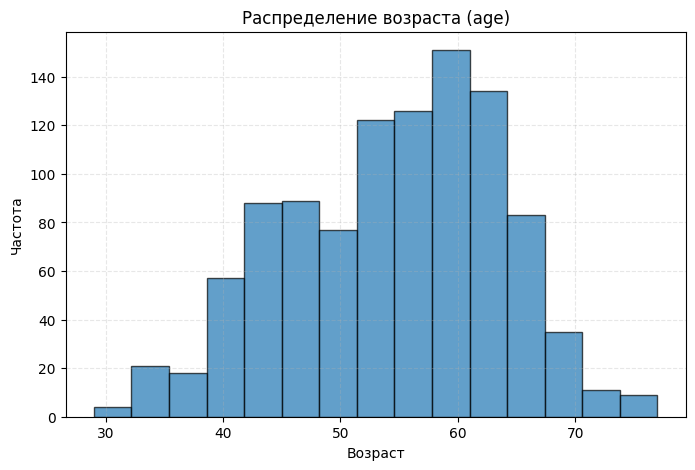

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(data["age"], bins=15, edgecolor="black", alpha=0.7)
plt.title("Распределение возраста (age)")
plt.xlabel("Возраст")
plt.ylabel("Частота")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

# Вывод

- Масштабировали числовой признак `age` с помощью `StandardScaler`, чтобы привести его к нулевому среднему и единичному стандартному отклонению и избежать влияния масштаба на обучение моделей.  
- Признак `cp` (тип боли в груди) закодировали двумя способами: `LabelEncoder` (целочисленная кодировка категорий) и `OneHotEncoder` (бинарные признаки для каждой категории).  
- Построили гистограмму для признака `age`, чтобы визуально оценить его распределение.